In [44]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Email_Spam_Detection_dataset.csv")
df.head()

,email_id,subject,email_length,num_links,num_exclamations,capital_letter_percent,has_offer,sender_domain,spam_score,label
0,1,Claim your reward,161.0,7.0,2,29.0,1,promo.net,100,spam
1,2,Win cash now,189.0,3.0,2,31.0,1,outlook.com,83,spam
2,3,Free vacation,201.0,5.0,2,35.0,1,company.com,100,spam
3,4,Project meeting,177.0,2.0,1,1.0,0,gmail.com,52,ham
4,5,Interview schedule,137.0,0.0,2,3.0,0,promo.net,22,ham


In [45]:
df = pd.read_csv("Email_Spam_Detection_dataset.csv")

In [46]:
df.head()

,email_id,subject,email_length,num_links,num_exclamations,capital_letter_percent,has_offer,sender_domain,spam_score,label
0,1,Claim your reward,161.0,7.0,2,29.0,1,promo.net,100,spam
1,2,Win cash now,189.0,3.0,2,31.0,1,outlook.com,83,spam
2,3,Free vacation,201.0,5.0,2,35.0,1,company.com,100,spam
3,4,Project meeting,177.0,2.0,1,1.0,0,gmail.com,52,ham
4,5,Interview schedule,137.0,0.0,2,3.0,0,promo.net,22,ham


In [47]:
df.columns

Index(['email_id', 'subject', 'email_length', 'num_links', 'num_exclamations',
       'capital_letter_percent', 'has_offer', 'sender_domain', 'spam_score',
       'label'],
      dtype='object')

In [49]:
# First 5 Rows
print("First 5 Rows")
print(df.head())

print("\n")

# Data Types
print("Data Types")
print(df.dtypes)

print("\n")

# Shape
print("Shape of Dataset")
print(df.shape)

First 5 Rows
   email_id             subject  email_length  num_links  num_exclamations  \
0         1   Claim your reward         161.0        7.0                 2   
1         2        Win cash now         189.0        3.0                 2   
2         3       Free vacation         201.0        5.0                 2   
3         4     Project meeting         177.0        2.0                 1   
4         5  Interview schedule         137.0        0.0                 2   

   capital_letter_percent  has_offer sender_domain  spam_score label  
0                    29.0          1     promo.net         100  spam  
1                    31.0          1   outlook.com          83  spam  
2                    35.0          1   company.com         100  spam  
3                     1.0          0     gmail.com          52   ham  
4                     3.0          0     promo.net          22   ham  


Data Types
email_id                    int64
subject                    object
email_lengt

In [11]:
# Missing Values Count
missing_count = df.isnull().sum()

# Missing Percentage
missing_percentage = (df.isnull().sum() / df.shape[0]) * 100

# Create Table
null_table = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

print(null_table)

                        Missing Count  Missing Percentage
email_id                            0             0.00000
subject                             0             0.00000
email_length                       12             1.95122
num_links                          12             1.95122
num_exclamations                    0             0.00000
capital_letter_percent             12             1.95122
has_offer                           0             0.00000
sender_domain                       0             0.00000
spam_score                          0             0.00000
label                               0             0.00000


In [54]:
print("Columns having more than 20% Missing Values")

print(null_table[null_table["Missing Percentage"] > 20])

Columns having more than 20% Missing Values
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []


In [55]:
numeric_columns = df.select_dtypes(include='number').columns

for col in numeric_columns:
    if (df[col].isnull().mean() * 100) < 20:
        df[col] = df[col].fillna(df[col].median())

print("Missing values filled using Median")

Missing values filled using Median


In [56]:
# Count duplicate rows
duplicate_count = df.duplicated().sum()

print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 15


In [57]:
# Rows before removing duplicates
rows_before = df.shape[0]

# Remove duplicate rows
df = df.drop_duplicates()

# Rows after removing duplicates
rows_after = df.shape[0]

# Number of removed rows
removed_rows = rows_before - rows_after

print("Rows Before:", rows_before)
print("Rows After :", rows_after)
print("Duplicates Removed:", removed_rows)

Rows Before: 615
Rows After : 600
Duplicates Removed: 15


In [58]:
# Null percentage after removing duplicates
new_null_percentage = (df.isnull().sum() / df.shape[0]) * 100

print(new_null_percentage)

email_id                  0.0
subject                   0.0
email_length              0.0
num_links                 0.0
num_exclamations          0.0
capital_letter_percent    0.0
has_offer                 0.0
sender_domain             0.0
spam_score                0.0
label                     0.0
dtype: float64


In [59]:
comparison = pd.DataFrame({
    "Before (%)": null_table["Missing Percentage"],
    "After (%)": new_null_percentage
})

print(comparison)

                        Before (%)  After (%)
email_id                   0.00000        0.0
subject                    0.00000        0.0
email_length               1.95122        0.0
num_links                  1.95122        0.0
num_exclamations           0.00000        0.0
capital_letter_percent     1.95122        0.0
has_offer                  0.00000        0.0
sender_domain              0.00000        0.0
spam_score                 0.00000        0.0
label                      0.00000        0.0


In [60]:
print(df.dtypes)

email_id                    int64
subject                    object
email_length              float64
num_links                 float64
num_exclamations            int64
capital_letter_percent    float64
has_offer                   int64
sender_domain              object
spam_score                  int64
label                      object
dtype: object


In [61]:
memory_before = df.memory_usage(deep=True).sum()

print("Memory Before:", memory_before, "bytes")

Memory Before: 143438 bytes


In [62]:
df["has_offer"] = df["has_offer"].astype("category")

df["sender_domain"] = df["sender_domain"].astype("category")

df["label"] = df["label"].astype("category")

In [63]:
memory_after = df.memory_usage(deep=True).sum()

print("Memory After :", memory_after, "bytes")

print("Memory Saved :", memory_before - memory_after, "bytes")

Memory After : 74561 bytes
Memory Saved : 68877 bytes


In [64]:
print(df.dtypes)

email_id                     int64
subject                     object
email_length               float64
num_links                  float64
num_exclamations             int64
capital_letter_percent     float64
has_offer                 category
sender_domain             category
spam_score                   int64
label                     category
dtype: object


In [65]:
# Descriptive Statistics
print(df.describe())

         email_id  email_length   num_links  num_exclamations  \
count  600.000000    600.000000  600.000000        600.000000   
mean   300.500000    126.726667    2.398333          2.891667   
std    173.349358     56.486221    2.285834          2.974561   
min      1.000000     30.000000    0.000000          0.000000   
25%    150.750000     83.000000    1.000000          1.000000   
50%    300.500000    126.000000    2.000000          2.000000   
75%    450.250000    163.000000    4.000000          5.000000   
max    600.000000    259.000000    8.000000         10.000000   

       capital_letter_percent  spam_score  
count              600.000000  600.000000  
mean                28.410000   57.985000  
std                 22.653709   31.750616  
min                  0.000000    1.000000  
25%                 12.000000   31.000000  
50%                 23.000000   45.000000  
75%                 40.000000  100.000000  
max                 90.000000  100.000000  


In [66]:
# Skewness
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns

skewness = df[numeric_columns].skew()

print(skewness)

email_id                  0.000000
email_length              0.344793
num_links                 1.002330
num_exclamations          1.119380
capital_letter_percent    1.006537
spam_score                0.252655
dtype: float64


In [67]:
def detect_outliers_iqr(column):

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print("--------------------------------")
    print("Column :", column)
    print("Q1 :", Q1)
    print("Q3 :", Q3)
    print("IQR :", IQR)
    print("Lower Bound :", lower)
    print("Upper Bound :", upper)
    print("Number of Outliers :", len(outliers))

In [68]:
detect_outliers_iqr("num_exclamations")

detect_outliers_iqr("capital_letter_percent")

--------------------------------
Column : num_exclamations
Q1 : 1.0
Q3 : 5.0
IQR : 4.0
Lower Bound : -5.0
Upper Bound : 11.0
Number of Outliers : 0
--------------------------------
Column : capital_letter_percent
Q1 : 12.0
Q3 : 40.0
IQR : 28.0
Lower Bound : -30.0
Upper Bound : 82.0
Number of Outliers : 15


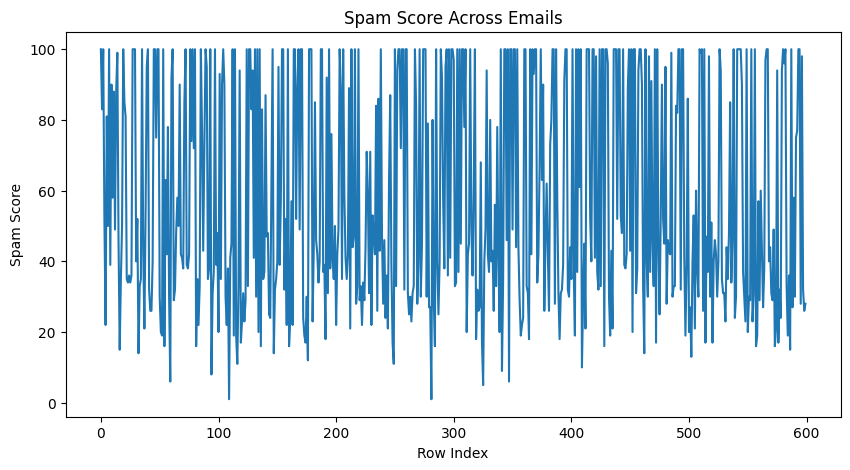

In [69]:
plt.figure(figsize=(10,5))

plt.plot(df.index, df["spam_score"])

plt.title("Spam Score Across Emails")
plt.xlabel("Row Index")
plt.ylabel("Spam Score")

plt.show()

/tmp/ipykernel_1435/957037273.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("label")["spam_score"].mean().plot(kind="bar", figsize=(6,5))


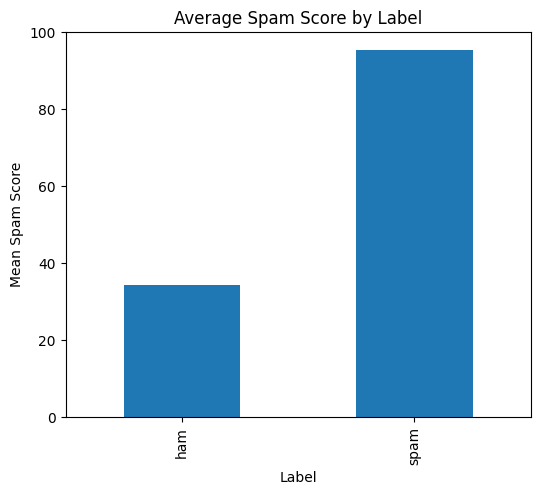

In [70]:
df.groupby("label")["spam_score"].mean().plot(kind="bar", figsize=(6,5))

plt.title("Average Spam Score by Label")
plt.xlabel("Label")
plt.ylabel("Mean Spam Score")

plt.show()

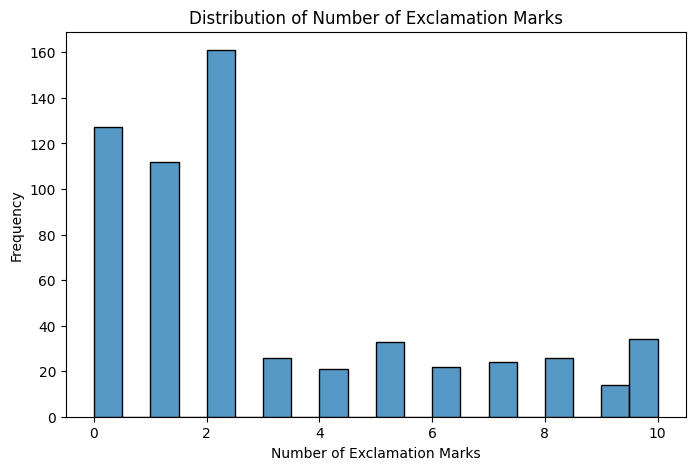

In [71]:
plt.figure(figsize=(8,5))

sns.histplot(df["num_exclamations"], bins=20)

plt.title("Distribution of Number of Exclamation Marks")
plt.xlabel("Number of Exclamation Marks")
plt.ylabel("Frequency")

plt.show()

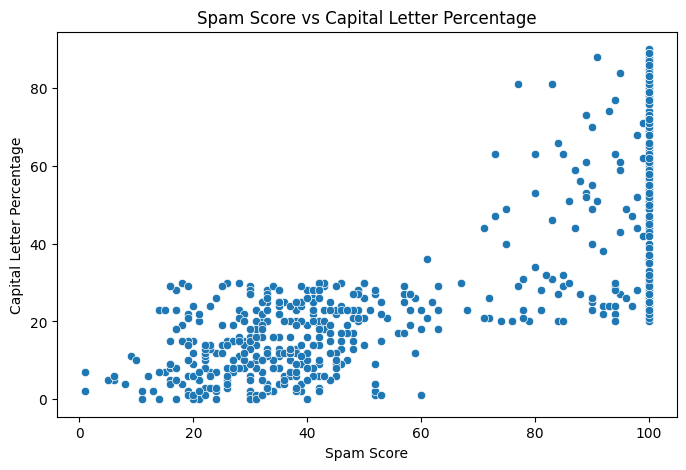

In [72]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="spam_score",
    y="capital_letter_percent",
    data=df
)

plt.title("Spam Score vs Capital Letter Percentage")
plt.xlabel("Spam Score")
plt.ylabel("Capital Letter Percentage")

plt.show()

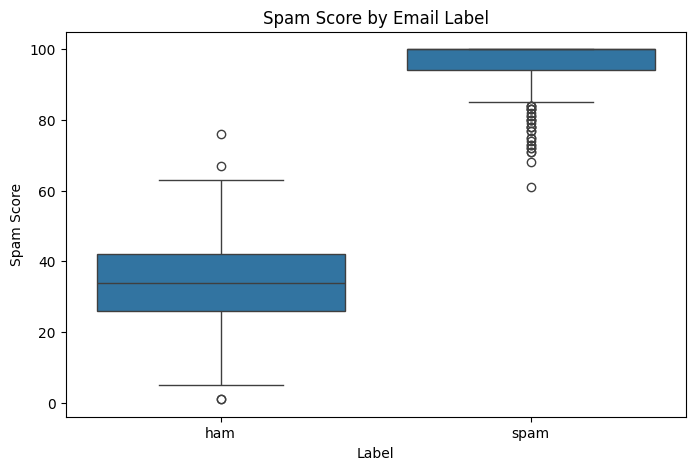

In [73]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="label",
    y="spam_score",
    data=df
)

plt.title("Spam Score by Email Label")
plt.xlabel("Label")
plt.ylabel("Spam Score")

plt.show()

In [74]:
# Pearson Correlation Matrix
pearson_corr = df.corr(numeric_only=True)

print(pearson_corr)

                        email_id  email_length  num_links  num_exclamations  \
email_id                1.000000     -0.008151   0.021173         -0.016196   
email_length           -0.008151      1.000000   0.391733          0.348147   
num_links               0.021173      0.391733   1.000000          0.618956   
num_exclamations       -0.016196      0.348147   0.618956          1.000000   
capital_letter_percent  0.037199      0.366447   0.587921          0.599914   
spam_score             -0.009796      0.580884   0.831096          0.786113   

                        capital_letter_percent  spam_score  
email_id                              0.037199   -0.009796  
email_length                          0.366447    0.580884  
num_links                             0.587921    0.831096  
num_exclamations                      0.599914    0.786113  
capital_letter_percent                1.000000    0.777068  
spam_score                            0.777068    1.000000  


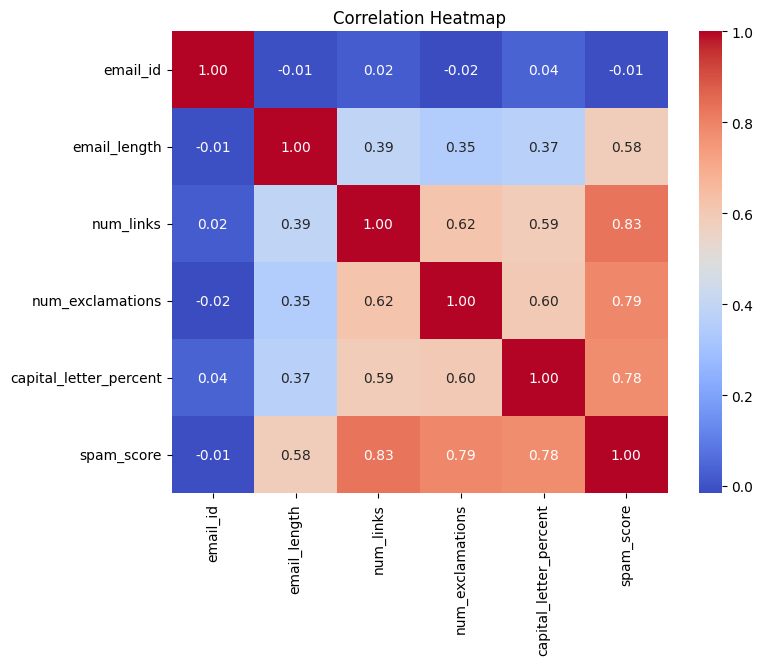

In [75]:
plt.figure(figsize=(8,6))

sns.heatmap(
    pearson_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [76]:
corr = pearson_corr.abs()

# Remove self-correlation
np.fill_diagonal(corr.values, 0)

highest_pair = corr.unstack().idxmax()
highest_value = corr.unstack().max()

print("Highest Correlation Pair:", highest_pair)
print("Correlation Value:", highest_value)

Highest Correlation Pair: ('num_links', 'spam_score')
Correlation Value: 0.8310961114863072


In [77]:
skew = df.select_dtypes(include=['int64','float64']).skew()

top2 = skew.abs().sort_values(ascending=False).head(2).index

print("Top 2 Highest Skewed Columns\n")

for col in top2:

    print("Column:", col)
    print("Mean :", df[col].mean())
    print("Median :", df[col].median())
    print("-"*30)

    df[col] = df[col].fillna(df[col].median())

Top 2 Highest Skewed Columns

Column: num_exclamations
Mean : 2.8916666666666666
Median : 2.0
------------------------------
Column: capital_letter_percent
Mean : 28.41
Median : 23.0
------------------------------


In [78]:
print(df[top2].isnull().sum())

num_exclamations          0
capital_letter_percent    0
dtype: int64


In [79]:
# Spearman Correlation
spearman_corr = df.corr(method="spearman", numeric_only=True)

print("Pearson Correlation")
print(pearson_corr)

print("\nSpearman Correlation")
print(spearman_corr)

Pearson Correlation
                        email_id  email_length  num_links  num_exclamations  \
email_id                1.000000     -0.008151   0.021173         -0.016196   
email_length           -0.008151      1.000000   0.391733          0.348147   
num_links               0.021173      0.391733   1.000000          0.618956   
num_exclamations       -0.016196      0.348147   0.618956          1.000000   
capital_letter_percent  0.037199      0.366447   0.587921          0.599914   
spam_score             -0.009796      0.580884   0.831096          0.786113   

                        capital_letter_percent  spam_score  
email_id                              0.037199   -0.009796  
email_length                          0.366447    0.580884  
num_links                             0.587921    0.831096  
num_exclamations                      0.599914    0.786113  
capital_letter_percent                1.000000    0.777068  
spam_score                            0.777068    1.000000  

In [80]:
difference = (spearman_corr - pearson_corr).abs()

print(difference)

                        email_id  email_length  num_links  num_exclamations  \
email_id                0.000000      0.011348   0.019523          0.005760   
email_length            0.011348      0.000000   0.027581          0.012505   
num_links               0.019523      0.027581   0.000000          0.045810   
num_exclamations        0.005760      0.012505   0.045810          0.000000   
capital_letter_percent  0.016293      0.010642   0.028091          0.027199   
spam_score              0.008354      0.008483   0.015766          0.028127   

                        capital_letter_percent  spam_score  
email_id                              0.016293    0.008354  
email_length                          0.010642    0.008483  
num_links                             0.028091    0.015766  
num_exclamations                      0.027199    0.028127  
capital_letter_percent                0.000000    0.016446  
spam_score                            0.016446    0.000000  


In [81]:
diff = difference.where(np.triu(np.ones(difference.shape), k=1).astype(bool))

top3 = diff.stack().sort_values(ascending=False).head(3)

print(top3)

num_links         num_exclamations          0.045810
num_exclamations  spam_score                0.028127
num_links         capital_letter_percent    0.028091
dtype: float64


In [82]:
grouped = df.groupby("label")["spam_score"].agg(["mean","std","count"])

print(grouped)

            mean        std  count
label                             
ham    34.250681  12.406033    367
spam   95.369099   8.081017    233


/tmp/ipykernel_1435/1518899347.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby("label")["spam_score"].agg(["mean","std","count"])


In [83]:
print("Highest Mean Group :", grouped["mean"].idxmax())
print("Highest Std Group :", grouped["std"].idxmax())

ratio = grouped["mean"].max() / grouped["mean"].min()

print("Mean Ratio :", ratio)

Highest Mean Group : spam
Highest Std Group : ham
Mean Ratio : 2.7844438526227377


In [84]:
df.to_csv("cleaned_data.csv", index=False)

print("cleaned_data.csv saved successfully")

cleaned_data.csv saved successfully
